# Matplotlib - Scatter Plots
___
- EG: `df.plot(kind='scatter')`
- These type of Plots are great at showing correlation between multiple Variables
- We are able to see how things like Median Salary correlate to the Count/Demand of a Skill in Job Postings
    - Spoiler alert, that's the Visualization that will be worked on in this lesson
    - Also, for the Insights of this, we will notice that Python will be up in the Top Right Corner, meaning it's not only a highly paid skill, but also has a high demand
    - This just shows you can get really good Insights out of these Types of Plots
- But as always, let's start with a simple example!
    - We will start by Creating this DataFrame filled with Fake Data
        - Starting of making a Dictionary with different **Keys** and **Values**
        - Inside of it, there's different job_skills, along with the made up Counts alongside their made up Pay
    - Then we Convert/Transform the Dictionary into a DataFrame
    - Then when it turns into a Dictionary, it can be Plotted!
        - Start by defining our `df` and Invoking the `.plot()` Function
        - Inside, Set the `kind='scatter'`
        - Providing the X Values as: `x='skill_count'`
        - Providing the Y Values as: `y='skill_pay'`

<Axes: xlabel='skill_count', ylabel='skill_pay'>

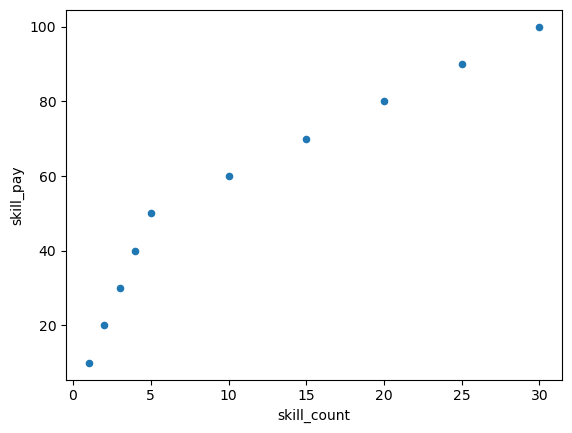

In [1]:
# Simple Scatter Plot Example
import pandas as pd

# Dictionary with Fake Data
data = {
    'job_skills': ['Python', 'SQL', 'Java', 'C++', 'C#', 'Javascript', 'HTML', 'CSS', 'PHP', 'Ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
}

# Converting Dictionary to DataFrame
df = pd.DataFrame(data)

# Plotting the DataFrame
df.plot(kind='scatter', x='skill_count', y='skill_pay')

- Running the above, we have our Scatter Plot! Super simple to make and to see the Information
- Granted this Chart needs to be Cleaned up as it's missing Labels and such but the bones of it is there
- Most important thing to understand is that we are able to Plot things by their X and Y Coordinates according to the Skill

- Now, on to making the Scatter Visualization that was mentioned at the start of the Lesson:
    - We need to get our Data in a form, similar to what we provided above
        - Wherby, `skill_pay` and `skill_count` aggregated by each of those Skills
    - So what we need to do is Create a DataFrame with 3 Columns, `job_skills`, `median_salary` and `skill_count` and sorted in Descending Order by `skill_count`
        - `job_skills` will be the **Index** and for each of those Skills, we'd need to know what the `median_salary` and `skill_count` are
    - The purpose of this Format, we can use the `median_salary` as the Y Axis and the `skill_count` as the X Axis on the Scatter Plot
    - Because the Skill and Pay is very dependent on the Job Title, the DataFrame is going to be Filtered down to just **Data Analyst**
        - Let's get cracking on this by doing our usual Data Imports and then Filtering the Data Set down for only Data Analyst Jobs
        - Then we will Explode out the `job_skills` Column and assign it to it's own DataFrame

In [2]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading the Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleaning the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

f:\Users\Neill\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Filtering and Replacing the Original DataFrame with only Data where the job_title is Data Analyst
df = df[df['job_title_short'] == 'Data Analyst']

# Exploding out the job_skills Column
df_exploded = df.explode('job_skills')

# Printing it out to show our work
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,azure,"{'cloud': ['aws', 'azure']}"
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sql,"{'analyst_tools': ['sas', 'excel'], 'programmi..."


- Next step is to do a Grouping... specifically for the `job_skills` we need to Group the job_skills in order to get:
    - The Count of these Skills
    - For the `salary_year_avg` Column, we need to Aggregate for each of those Skills to get the Median Salary back
- Using the Exploded DataFrame of `df_exploded`:
    - Using the `.groupby()` Function on it
        - Passing in `job_skills`
        - Then to see the Count, we use the `.size()` Function
    - Now, we not only want the Counts of these Skills, but also the Associated Median Salary
        - Since there's multiple Aggregation Functions happening, we need to invoke the `.agg()` Function
        - In here, we can pass in multiple Aggregations, in the case, `'size'` and `'median'`
            - But to do that, we are going to do something that we haven't done before
            - We will be using basically like a Dictionary in order to find Key and Values for how we want to do these different Aggregations
            - We will start with `skill_count`:
                - We want to name the New Column skill_count, so we start by invoking `skill_count`
                - Then set it Equal to a Tuple of 2 Variables, like so: `skill_count=('', '')` 
                - We will need to Pass in the Column we want to do the Aggregation on so: `'job_skills'`
                - Then Pass in the Aggregation Method that we want to do, in this case it's: `'count'`
                    - To Reiterate: `skill_count` is the New Column Name, then, using the `job_skills` Column to Perform a Count
            - We also want to do `median_salary`:
                - We want to name the New Column median_salary, so we start by invoking `median_salary`
                - Then set it Equal to a Tuple of 2 Variables, like so: `median_salary=('', '')` 
                - We will need to Pass in the Column we want to do the Aggregation on so: `'salary_year_avg'`
                - Then Pass in the Aggregation Method that we want to do, in this case it's: `'median'`
                    - To Reiterate: `median_salary` is the New Column Name, then, using the `salary_year_avg` Column to Perform Median
- After we do all that and Run it, we now have 2 New Columns Created called skill_count and median_salary side by side
- Now we Assign the DataFrame that we got back to a New Variable called `skill_stats`
    - This is so we can Sort the Values of it Properly, because right now it's out of Order, it's only in Alphabetical Order by the Names
    - We will want to Sort these Values by the `skill_count` Column in Descending Order
        - To do this we will start by:
            - Calling our Variable `skill_stats`
            - Invoking the `.sort_values()` Function
            - Passing in what Column we want to Sort by: `by='skill_count'`
            - Passing in that we want it in Descending Order by: `ascending=False`
            - Because we only want the Top 10 Values back, we can do this by invoking: `.head(10)`
    - This Returns our Top 10 `skill_counts` with the highest Values up at the Top!
- Setting all of this, equal to a Variable since it has everything Sorted correctly and Returning only the Values we want (Top 10)
    - Like always we just use: `skills_stats = skill_stats.sort_values(...)`

In [7]:
# Grouping by the Skills and Creating 2 New Columns of skill_count and median_salary showing the associated Values to those Skills
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skills_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

- Now that we have everything we need, the last thing we need to do, is to Plot it!

<Axes: xlabel='skill_count', ylabel='median_salary'>

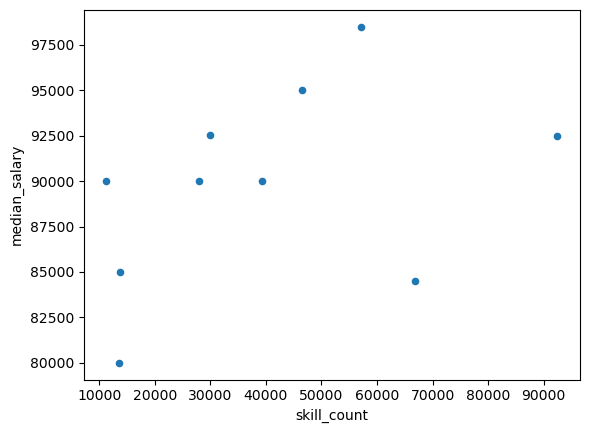

In [ ]:
# Plotting our Top 10 Skills to see how Median Salary correlates to the Count/Demand of a Skill
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')